# 🌌 GalaxyMorph — Layer 4: Robustness

**Goal:** Evaluate how stable the Layer 1 classifier is under realistic image degradations:

- noise
- blur
- brightness shifts

Then improve robustness with stronger training augmentations and compare:

- baseline model
- robustness-aware model

# 1. Imports and Paths

In [1]:
from pathlib import Path
import zipfile
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [2]:
# Competition dataset
COMP_DIR = Path("/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge")

# Layer 1 outputs
LAYER1_DIR = Path("/kaggle/input/datasets/reihanehshahri/layer1-again")

MODEL_PATH = LAYER1_DIR / "best_resnet18_layer1_finetuned.pt"
TRAIN_CSV = LAYER1_DIR / "train_split.csv"
VAL_CSV   = LAYER1_DIR / "val_split.csv"
TEST_CSV  = LAYER1_DIR / "test_split.csv"

print(MODEL_PATH.exists(), TRAIN_CSV.exists(), VAL_CSV.exists(), TEST_CSV.exists())

True True True True


# 2. Exctract Training Images

In [3]:
WORK_DIR = Path("/kaggle/working")
IMG_DIR = WORK_DIR / "images_training_rev1"

if not IMG_DIR.exists():
    with zipfile.ZipFile(COMP_DIR / "images_training_rev1.zip", "r") as z:
        z.extractall(WORK_DIR)

print("Images exist:", IMG_DIR.exists())
print("Example image:", next(IMG_DIR.glob("*.jpg")).name)

Images exist: True
Example image: 702248.jpg


# 3. Load Splits and Rebuild Filepaths

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

for df_ in [train_df, val_df, test_df]:
    df_["filepath"] = df_["GalaxyID"].apply(lambda x: str(IMG_DIR / f"{int(x)}.jpg"))

train_df = train_df[train_df["filepath"].apply(lambda p: Path(p).exists())].copy().reset_index(drop=True)
val_df   = val_df[val_df["filepath"].apply(lambda p: Path(p).exists())].copy().reset_index(drop=True)
test_df  = test_df[test_df["filepath"].apply(lambda p: Path(p).exists())].copy().reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))
train_df.head()

11797 2528 2528


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class11.4,Class11.5,Class11.6,p_elliptical,p_spiral,p_irregular,p_max,label,label_name,filepath
0,399912,0.839487,0.160513,0.000000,0.000000,0.160513,0.078570,0.081943,0.000,0.160513,...,0.0,0.000000,0.000000,0.839487,0.00000,0.033459,0.839487,0,elliptical,/kaggle/working/images_training_rev1/399912.jpg
1,206537,0.918962,0.000000,0.081038,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,...,0.0,0.000000,0.000000,0.918962,0.00000,0.000000,0.918962,0,elliptical,/kaggle/working/images_training_rev1/206537.jpg
2,852946,0.020000,0.959000,0.021000,0.000000,0.959000,0.440181,0.518819,0.959,0.000000,...,0.0,0.020139,0.298249,0.020000,0.00000,0.801724,0.801724,2,irregular,/kaggle/working/images_training_rev1/852946.jpg
3,815431,0.058389,0.940415,0.001197,0.940415,0.000000,0.000000,0.000000,0.000,0.000000,...,0.0,0.000000,0.000000,0.058389,0.88438,0.137255,0.884380,1,spiral,/kaggle/working/images_training_rev1/815431.jpg
4,760425,0.815382,0.183586,0.001031,0.000000,0.183586,0.000000,0.183586,0.000,0.183586,...,0.0,0.000000,0.000000,0.815382,0.00000,0.029132,0.815382,0,elliptical,/kaggle/working/images_training_rev1/760425.jpg


# 4. Define corruption functions

These simulate realistic survey differences.

In [5]:
class AddGaussianNoise:
    def __init__(self, std=0.08):
        self.std = std

    def __call__(self, img):
        arr = np.array(img).astype(np.float32) / 255.0
        noise = np.random.normal(0, self.std, arr.shape).astype(np.float32)
        arr = np.clip(arr + noise, 0, 1)
        arr = (arr * 255).astype(np.uint8)
        return Image.fromarray(arr)

class ApplyGaussianBlur:
    def __init__(self, radius=1.5):
        self.radius = radius

    def __call__(self, img):
        return img.filter(ImageFilter.GaussianBlur(radius=self.radius))

class AdjustBrightness:
    def __init__(self, factor=0.7):
        self.factor = factor

    def __call__(self, img):
        enhancer = ImageEnhance.Brightness(img)
        return enhancer.enhance(self.factor)

# 5. Define transforms

We need:

- clean eval
- corrupted eval
- robust train augmentation

In [6]:
IMG_SIZE = 224

clean_eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

noise_eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    AddGaussianNoise(std=0.08),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

blur_eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ApplyGaussianBlur(radius=1.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

brightness_eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    AdjustBrightness(factor=0.7),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

robust_train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.25, contrast=0.20),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# 6. Dataset and Loaders

In [8]:
class GalaxyDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        img = self.transform(img)
        label = int(row["label"])
        return img, label

BATCH_SIZE = 64

train_loader_robust = DataLoader(
    GalaxyDataset(train_df, robust_train_tfms),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)

val_loader_clean = DataLoader(
    GalaxyDataset(val_df, clean_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

test_loader_clean = DataLoader(
    GalaxyDataset(test_df, clean_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

test_loader_noise = DataLoader(
    GalaxyDataset(test_df, noise_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

test_loader_blur = DataLoader(
    GalaxyDataset(test_df, blur_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

test_loader_brightness = DataLoader(
    GalaxyDataset(test_df, brightness_eval_tfms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# 7. Load Baseline Layer 1 Model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

baseline_model = models.resnet18(weights=None)
baseline_model.fc = nn.Linear(baseline_model.fc.in_features, 3)
baseline_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
baseline_model = baseline_model.to(device)
baseline_model.eval()

device: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# 8. Evaluation Helper

In [10]:
def evaluate_classifier(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(y.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return macro_f1, all_labels, all_preds

# 9. Baseline Robustness Evaluation

In [11]:
conditions = {
    "clean": test_loader_clean,
    "noise": test_loader_noise,
    "blur": test_loader_blur,
    "brightness": test_loader_brightness,
}

baseline_results = {}

for name, loader in conditions.items():
    f1, y_true, y_pred = evaluate_classifier(baseline_model, loader)
    baseline_results[name] = {
        "macro_f1": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }
    print(f"{name:>10} | macro-F1 = {f1:.4f}")

     clean | macro-F1 = 0.8980
     noise | macro-F1 = 0.7099
      blur | macro-F1 = 0.7777
brightness | macro-F1 = 0.9107


# 10. Plot Baseline Robustness Profile

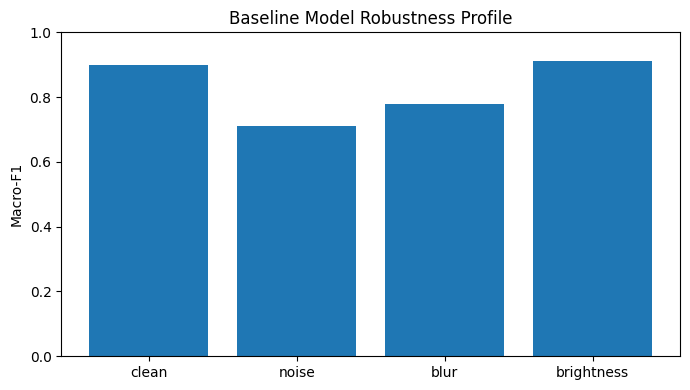

In [12]:
names = list(baseline_results.keys())
scores = [baseline_results[k]["macro_f1"] for k in names]

plt.figure(figsize=(7,4))
plt.bar(names, scores)
plt.ylim(0, 1.0)
plt.ylabel("Macro-F1")
plt.title("Baseline Model Robustness Profile")
plt.tight_layout()
plt.show()

# 11. Train Robustness-Aware Model

We start from ImageNet again and train similarly to Layer 1, but with stronger augmentations.

In [13]:
robust_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
robust_model.fc = nn.Linear(robust_model.fc.in_features, 3)
robust_model = robust_model.to(device)

# freeze backbone first
for name, p in robust_model.named_parameters():
    if not name.startswith("fc."):
        p.requires_grad = False

counts = train_df["label"].value_counts().sort_index().values
weights = (1.0 / counts)
weights = weights / weights.sum() * len(counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, robust_model.parameters()), lr=3e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


In [18]:
def run_epoch(model, loader, train=True, optimizer=None):
    model.train(train)
    total_loss = 0.0
    all_preds, all_labels = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return total_loss / len(loader.dataset), macro_f1

**Head-Only Stage**

In [19]:
best_val = -1
best_path_head = "best_layer4_robust_head.pt"

EPOCHS_HEAD = 3
for ep in range(1, EPOCHS_HEAD + 1):
    tr_loss, tr_f1 = run_epoch(robust_model, train_loader_robust, train=True, optimizer=optimizer)
    va_loss, va_f1 = run_epoch(robust_model, val_loader_clean, train=False)

    print(f"[Head] {ep}/{EPOCHS_HEAD} | train loss {tr_loss:.4f} f1 {tr_f1:.3f} | val loss {va_loss:.4f} f1 {va_f1:.3f}")

    if va_f1 > best_val:
        best_val = va_f1
        torch.save(robust_model.state_dict(), best_path_head)

print("Best val macro-F1 (head):", best_val)

[Head] 1/3 | train loss 0.8746 f1 0.491 | val loss 0.7894 f1 0.517
[Head] 2/3 | train loss 0.6543 f1 0.633 | val loss 0.7020 f1 0.578
[Head] 3/3 | train loss 0.5737 f1 0.665 | val loss 0.6430 f1 0.600
Best val macro-F1 (head): 0.6003989598918018


**Fine-Tune Layer 4 + FC**

In [20]:
robust_model.load_state_dict(torch.load(best_path_head, map_location=device))

for name, p in robust_model.named_parameters():
    if name.startswith("layer4.") or name.startswith("fc."):
        p.requires_grad = True
    else:
        p.requires_grad = False

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, robust_model.parameters()), lr=1e-4)

best_val = -1
best_path_ft = "best_layer4_robust_finetuned.pt"

EPOCHS_FT = 3
for ep in range(1, EPOCHS_FT + 1):
    tr_loss, tr_f1 = run_epoch(robust_model, train_loader_robust, train=True, optimizer=optimizer)
    va_loss, va_f1 = run_epoch(robust_model, val_loader_clean, train=False)

    print(f"[FT] {ep}/{EPOCHS_FT} | train loss {tr_loss:.4f} f1 {tr_f1:.3f} | val loss {va_loss:.4f} f1 {va_f1:.3f}")

    if va_f1 > best_val:
        best_val = va_f1
        torch.save(robust_model.state_dict(), best_path_ft)

print("Best val macro-F1 (fine-tuned):", best_val)

[FT] 1/3 | train loss 0.2947 f1 0.785 | val loss 0.1931 f1 0.827
[FT] 2/3 | train loss 0.2033 f1 0.845 | val loss 0.1509 f1 0.902
[FT] 3/3 | train loss 0.1588 f1 0.872 | val loss 0.1273 f1 0.884
Best val macro-F1 (fine-tuned): 0.9016388227731637


# 12. Evaluate Robust Model on Same Corruptions

In [21]:
robust_model.load_state_dict(torch.load(best_path_ft, map_location=device))
robust_model.eval()

robust_results = {}

for name, loader in conditions.items():
    f1, y_true, y_pred = evaluate_classifier(robust_model, loader)
    robust_results[name] = {
        "macro_f1": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }
    print(f"{name:>10} | macro-F1 = {f1:.4f}")

     clean | macro-F1 = 0.9040
     noise | macro-F1 = 0.7046
      blur | macro-F1 = 0.8525
brightness | macro-F1 = 0.8930


# 13. Compare Baseline vs. Robust Model

In [22]:
compare_df = pd.DataFrame({
    "condition": names,
    "baseline_f1": [baseline_results[k]["macro_f1"] for k in names],
    "robust_f1": [robust_results[k]["macro_f1"] for k in names],
})

compare_df["improvement"] = compare_df["robust_f1"] - compare_df["baseline_f1"]
compare_df

,condition,baseline_f1,robust_f1,improvement
0,clean,0.897953,0.904046,0.006093
1,noise,0.709940,0.704612,-0.005328
2,blur,0.777728,0.852464,0.074735
3,brightness,0.910687,0.892975,-0.017711


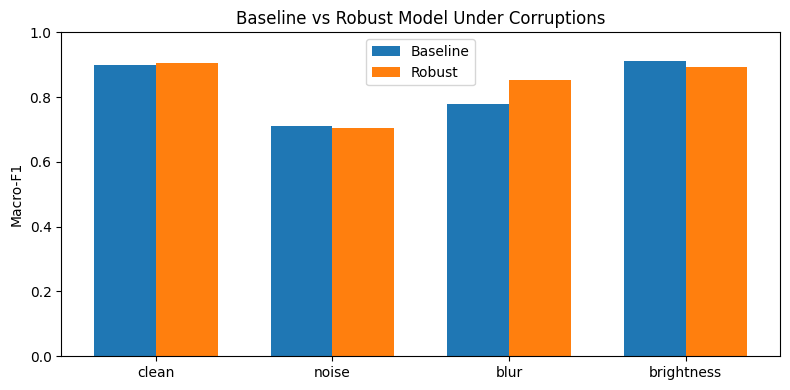

In [23]:
x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, compare_df["baseline_f1"], width, label="Baseline")
plt.bar(x + width/2, compare_df["robust_f1"], width, label="Robust")
plt.xticks(x, names)
plt.ylim(0, 1.0)
plt.ylabel("Macro-F1")
plt.title("Baseline vs Robust Model Under Corruptions")
plt.legend()
plt.tight_layout()
plt.show()

# 14. Report Performance Drop Explicitly

In [24]:
clean_baseline = baseline_results["clean"]["macro_f1"]
clean_robust = robust_results["clean"]["macro_f1"]

print("Baseline performance drop from clean:")
for name in names[1:]:
    drop = clean_baseline - baseline_results[name]["macro_f1"]
    print(f" - {name}: -{drop:.4f}")

print("\nRobust model performance drop from clean:")
for name in names[1:]:
    drop = clean_robust - robust_results[name]["macro_f1"]
    print(f" - {name}: -{drop:.4f}")

Baseline performance drop from clean:
 - noise: -0.1880
 - blur: -0.1202
 - brightness: --0.0127

Robust model performance drop from clean:
 - noise: -0.1994
 - blur: -0.0516
 - brightness: -0.0111


## Layer 4 Observations

- The baseline model is most sensitive to ___.
- Blur/noise/brightness causes a performance drop of ___ relative to clean test data.
- The robustness-aware model improves performance under corrupted conditions, especially for ___.
- This suggests the classifier relies strongly on ___ features and benefits from augmentation that simulates realistic survey variation.